# Machine learning

In this notebook, we use the K-Nearest Neighbors algorithm to predict the listening diversity of a user.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [11]:
user_features = pd.read_csv("data/user_features.csv", index_col="user_id")

In [23]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),
}

In [13]:
# Select numeric columns
numeric_cols = user_features.select_dtypes(include=["int64", "float64"]).columns

# Drop target and directly-related columns from features
feature_cols = numeric_cols.drop(
    ["genre_diversity", "high_genre_diversity"], errors="ignore"
)

X = user_features[feature_cols].copy()
y = user_features["high_genre_diversity"].copy()


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance similar in train/test
)

In [24]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

Training KNN...
Training Logistic Regression...
Training Random Forest...


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.669392,0.623486,0.846319,0.718011
1,Logistic Regression,0.628510,0.617219,0.666190,0.640770
2,Random Forest,0.752222,0.734940,0.784846,0.759074


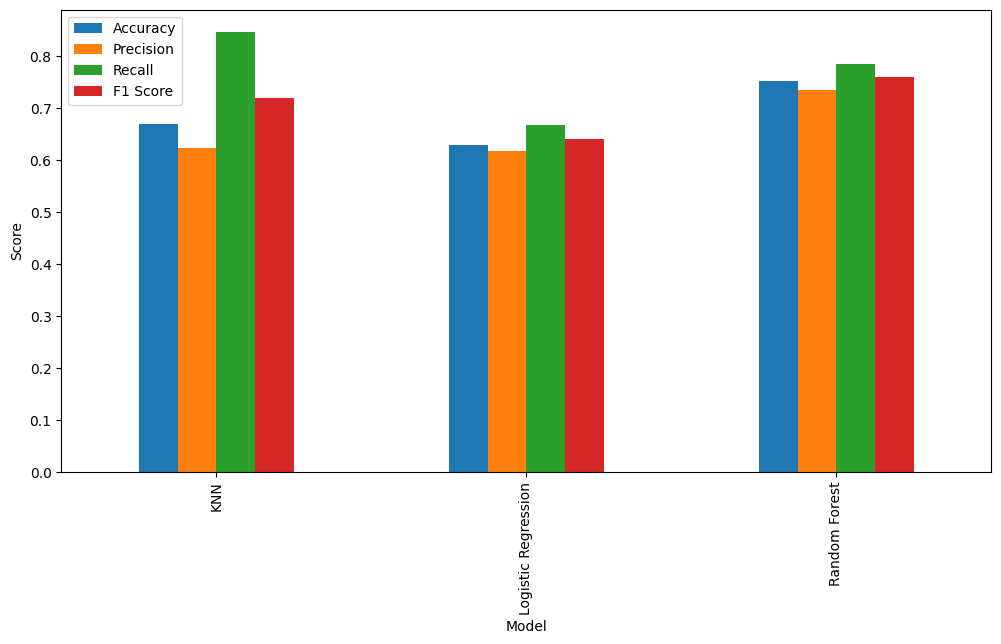

In [30]:
results_df.set_index("Model").plot.bar(figsize=(12,6))
plt.ylabel("Score")
plt.show()